In [1]:
#cell 1
# Εισαγωγή απαραίτητων βιβλιοθηκών
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns # <--- ΠΡΟΣΘΗΚΗ ΑΥΤΗΣ ΤΗΣ ΓΡΑΜΜΗΣ
import time
import logging # Προστέθηκε για καλύτερη καταγραφή
from tqdm.notebook import tqdm # Για μπάρες προόδου
# from sklearn.utils import resample # Θα το εισάγουμε στο Cell 9 αν χρειαστεί
# !pip install scikit-learn # Αν τρέχετε τοπικά και δεν είναι ήδη εγκατεστημένο
# !pip install seaborn # Αν τρέχετε τοπικά και δεν είναι ήδη εγκατεστημένο

# --- Παράμετροι Πειράματος ---
CONFIG = {
    "ACC_A_TRUE": 0.85,  # Πραγματική ακρίβεια Ταξινομητή Α
    "ACC_B_TRUE": 0.70,  # Πραγματική ακρίβεια Ταξινομητή Β
    "SAMPLE_SIZES": [100, 1000, 10000],  # Μεγέθη δείγματος Ν προς δοκιμή
    "B_REPLICATIONS": 1_000_000,  # Αριθμός bootstrap επαναλήψεων για την κύρια ανάλυση
                                     # Μπορεί να μειωθεί για δοκιμές (π.χ. 10_000)
    "B_REPLICATIONS_VIS_DIST": 10_000, # Για το ιστόγραμμα της κατανομής bootstrap (ταχύτητα)
    "B_REPLICATIONS_COMPARE": 10_000, # Για τη σύγκριση με scipy.stats.bootstrap (ταχύτητα)
    "P_VALUE_THRESHOLD": 0.01,   # Όριο σημαντικότητας p-value (α)
    "CONFIDENCE_LEVEL": 0.99,    # Επίπεδο εμπιστοσύνης για τα CIs (π.χ., 0.99 για 99% CI)
    "DELTAS": [0.0, 0.05, 0.10], # Τιμές δέλτα για τις υποθέσεις H1: Acc_A > Acc_B + δ
    "RANDOM_SEED": 42,           # Seed για αναπαραγωγιμότητα
    "OUTPUT_CSV_FILE": "bootstrap_test_summary_final.csv", # Αρχείο CSV για τα αποτελέσματα
    "OUTPUT_PLOT_PVAL_COMBINED": "pvalue_trends_combined_final.png", # Γράφημα p-values (συνδυασμένο)
    "OUTPUT_PLOT_PVAL_DELTA_PREFIX": "pvalue_trend_delta_",          # Πρόθεμα για ξεχωριστά p-value plots
    "OUTPUT_PLOT_CI_DELTA_PREFIX": "ci_trend_delta_",                # Πρόθεμα για CI trend plots
    "OUTPUT_PLOT_DIST_PREFIX": "bootstrap_dist_N"                    # Πρόθεμα για distribution plots
}

# --- Ρύθμιση Logging ---
logging.basicConfig(level=logging.INFO, # Ορισμός επιπέδου καταγραφής (INFO, DEBUG, WARNING, ERROR)
                    format='%(asctime)s - %(levelname)s - %(filename)s:%(lineno)d - %(message)s',
                    datefmt='%Y-%m-%d %H:%M:%S')

# Το global seed θα μπορούσε να οριστεί εδώ, αλλά προτιμάμε να περνάμε seeds στις συναρτήσεις
# για καλύτερο έλεγχο της τυχαιότητας σε κάθε βήμα.
# np.random.seed(CONFIG["RANDOM_SEED"])

logging.info("Οι βιβλιοθήκες φορτώθηκαν και οι παράμετροι ορίστηκαν.")

In [2]:
#cell 2
# Συνάρτηση για τη στοχαστική παραγωγή προβλέψεων των ταξινομητών
def generate_predictions(n_samples, acc_a, acc_b, seed=None):
    """
    Παράγει δυαδικές προβλέψεις (σωστό/λάθος) για τους ταξινομητές Α και Β.
    
    Παράμετροι:
    -----------
    n_samples : int
        Αριθμός δειγμάτων (N)
    acc_a : float
        Ακρίβεια ταξινομητή Α
    acc_b : float
        Ακρίβεια ταξινομητή Β
    seed : int, optional
        Τυχαίος σπόρος (seed) για αναπαραγωγιμότητα αυτής της προσομοίωσης.
        
    Επιστρέφει:
    --------
    pred_a : numpy.ndarray
        Δυαδικές προβλέψεις για τον ταξινομητή Α (1 = σωστό, 0 = λάθος)
    pred_b : numpy.ndarray
        Δυαδικές προβλέψεις για τον ταξινομητή Β (1 = σωστό, 0 = λάθος)
    """
    # Δημιουργία αντικειμένου RandomState για ελεγχόμενη τυχαιότητα αν δοθεί seed
    rng = np.random.RandomState(seed) if seed is not None else np.random
    
    # Παραγωγή τυχαίων τιμών και σύγκριση με τα όρια ακρίβειας
    rand_a = rng.random(n_samples) # Χρήση του rng για παραγωγή τυχαίων αριθμών
    rand_b = rng.random(n_samples)
    
    # Προβλέψεις ταξινομητή Α (1 αν τυχαία τιμή < ακρίβεια, 0 αλλιώς)
    pred_a = np.where(rand_a < acc_a, 1, 0)
    
    # Προβλέψεις ταξινομητή Β (1 αν τυχαία τιμή < ακρίβεια, 0 αλλιώς)
    pred_b = np.where(rand_b < acc_b, 1, 0)
    
    logging.debug(f"Προσομοιώθηκαν {n_samples} αποτελέσματα. Seed που χρησιμοποιήθηκε: {seed if seed is not None else 'Global np.random'}")
    return pred_a, pred_b

In [3]:
#cell 3
# Συνάρτηση για την εκτέλεση του paired bootstrap test
def paired_bootstrap_test(pred_a, pred_b, num_bootstraps, deltas, confidence_level=0.99, seed=None, return_distribution=False):
    """
    Εκτελεί paired bootstrap test για τη σύγκριση δύο ταξινομητών.
    Υπολογίζει p-values και διαστήματα εμπιστοσύνης για τη διαφορά στις ακρίβειες.
    """
    rng = np.random.RandomState(seed) if seed is not None else np.random
    n_samples = len(pred_a)
    
    if n_samples == 0:
        logging.warning("Οι πίνακες εισόδου είναι κενοί. Επιστροφή NaNs.")
        nan_ci = (np.nan, np.nan)
        if return_distribution:
            return [np.nan] * len(deltas), nan_ci, np.array([])
        else:
            return [np.nan] * len(deltas), nan_ci

    # Υπολογισμός διαφορών για κάθε bootstrap δείγμα
    diff_scores = np.zeros(num_bootstraps)
    
    # from tqdm.notebook import tqdm # Έχει ήδη γίνει import
    
    for i in tqdm(range(num_bootstraps), desc="Bootstrap επαναλήψεις", leave=False):
        # Δειγματοληψία δεικτών με επανατοποθέτηση
        indices = rng.randint(0, n_samples, n_samples) # Χρήση του rng
        
        # Υπολογισμός ακριβειών στο bootstrap δείγμα
        acc_a_boot = np.mean(pred_a[indices])
        acc_b_boot = np.mean(pred_b[indices])
        
        # Αποθήκευση της διαφοράς στις ακρίβειες
        diff_scores[i] = acc_a_boot - acc_b_boot
    
    # Υπολογισμός p-values για κάθε δέλτα
    p_values = []
    for delta in deltas:
        # Το p-value είναι το ποσοστό των bootstrap δειγμάτων όπου η διαφορά 
        # είναι μικρότερη ή ίση με το δέλτα (H0: Acc_A - Acc_B <= delta)
        p_value = np.mean(diff_scores <= delta)
        p_values.append(p_value)
        
    # Υπολογισμός Διαστήματος Εμπιστοσύνης για τη διαφορά Acc_A - Acc_B
    alpha_ci = 1.0 - confidence_level # π.χ. 1.0 - 0.99 = 0.01
    lower_percentile = (alpha_ci / 2.0) * 100 # π.χ. (0.01 / 2) * 100 = 0.5
    upper_percentile = (1.0 - (alpha_ci / 2.0)) * 100 # π.χ. (1 - 0.005) * 100 = 99.5
    
    ci_lower = np.percentile(diff_scores, lower_percentile)
    ci_upper = np.percentile(diff_scores, upper_percentile)
    ci = (ci_lower, ci_upper)
    
    logging.debug(f"Paired bootstrap test ολοκληρώθηκε. Seed: {seed if seed is not None else 'Global'}. CI: ({ci_lower:.4f}, {ci_upper:.4f})")

    if return_distribution:
        return p_values, ci, diff_scores
    else:
        return p_values, ci

In [4]:
#cell 4
# Συνάρτηση για την εκτέλεση του πειράματος για όλα τα μεγέθη δείγματος
def run_experiment(config_params):
    """
    Εκτελεί το bootstrap πείραμα για όλα τα μεγέθη δείγματος χρησιμοποιώντας τις παραμέτρους από το config_params.
    """
    results_log = {} # Λεξικό για την αποθήκευση των αποτελεσμάτων
    
    # Χρήση tqdm για την εξωτερική επανάληψη πάνω στα μεγέθη δείγματος
    for n_current in tqdm(config_params["SAMPLE_SIZES"], desc="Επεξεργασία Μεγεθών Δείγματος (N)"):
        logging.info(f"--- Εκτέλεση πειράματος για N = {n_current} ---")
        
        # Βήμα 1: Παραγωγή προβλέψεων
        logging.info("Παραγωγή προβλέψεων...")
        # Χρήση διαφορετικού seed για την προσομοίωση κάθε Ν, για ανεξαρτησία
        simulation_seed = config_params["RANDOM_SEED"] + n_current 
        predictions_a, predictions_b = generate_predictions(
            n_current, 
            config_params["ACC_A_TRUE"], 
            config_params["ACC_B_TRUE"],
            seed=simulation_seed
        )
        
        observed_acc_a = np.mean(predictions_a)
        observed_acc_b = np.mean(predictions_b)
        observed_diff = observed_acc_a - observed_acc_b # Παρατηρούμενη διαφορά
        logging.info(f"N={n_current}: Παρατηρούμενη AccA={observed_acc_a:.4f}, AccB={observed_acc_b:.4f}, Παρατηρούμενη Διαφορά={observed_diff:.4f}")
        
        # Βήμα 2: Εκτέλεση paired bootstrap test
        logging.info(f"Εκτέλεση paired bootstrap test με {config_params['B_REPLICATIONS']:,} επαναδειγματοληψίες για N={n_current}...")
        start_time_bootstrap = time.time()
        
        # Χρήση διαφορετικού seed για το bootstrap test κάθε Ν
        bootstrap_seed = config_params["RANDOM_SEED"] + n_current + sum(config_params["SAMPLE_SIZES"]) # Εξασφάλιση διαφορετικού seed
        
        p_values_list, confidence_interval = paired_bootstrap_test(
            predictions_a, 
            predictions_b, 
            config_params["B_REPLICATIONS"], 
            config_params["DELTAS"],
            confidence_level=config_params["CONFIDENCE_LEVEL"],
            seed=bootstrap_seed,
            return_distribution=False # Δεν χρειαζόμαστε την κατανομή για την κύρια ανάλυση
        )
        
        end_time_bootstrap = time.time()
        logging.info(f"Bootstrap test για N={n_current} ολοκληρώθηκε σε {end_time_bootstrap - start_time_bootstrap:.2f} δευτερόλεπτα")
        
        # Αποθήκευση αποτελεσμάτων
        results_log[n_current] = {
            'acc_a': observed_acc_a,
            'acc_b': observed_acc_b,
            'observed_diff': observed_diff, # Αποθήκευση της παρατηρούμενης διαφοράς
            'delta_values': config_params["DELTAS"],
            'p_values': p_values_list,
            'confidence_interval': confidence_interval, # Αποθήκευση του CI
            'reject_h0': [p < config_params["P_VALUE_THRESHOLD"] for p in p_values_list]
        }
        
        # Καταγραφή αποτελεσμάτων για το τρέχον Ν
        logging.info(f"Αποτελέσματα Bootstrap Test για N = {n_current}:")
        logging.info(f"  {int(config_params['CONFIDENCE_LEVEL']*100)}% CI για AccA-AccB: ({confidence_interval[0]:.4f}, {confidence_interval[1]:.4f})")
        for i, delta_current in enumerate(config_params["DELTAS"]):
            rejection_status = "Ναι" if p_values_list[i] < config_params["P_VALUE_THRESHOLD"] else "Όχι"
            logging.info(f"  H1: Acc_A > Acc_B + {delta_current:.2f} -> p-value = {p_values_list[i]:.6f}, Απόρριψη H0 (α={config_params['P_VALUE_THRESHOLD']}): {rejection_status}")
        logging.info(f"--- Πείραμα για N = {n_current} ολοκληρώθηκε ---")
            
    return results_log

In [5]:
#cell 5
# Για δοκιμές, μπορείτε να μειώσετε τον αριθμό των bootstrap επαναλήψεων αλλάζοντας
# την τιμή CONFIG["B_REPLICATIONS"] στο Cell 1 (π.χ., CONFIG["B_REPLICATIONS"] = 10_000)

logging.info("===== ΕΝΑΡΞΗ ΚΥΡΙΟΥ ΠΕΙΡΑΜΑΤΟΣ =====")
results = run_experiment(CONFIG) # Περνάμε το λεξικό CONFIG
logging.info("===== ΟΛΟΚΛΗΡΩΣΗ ΚΥΡΙΟΥ ΠΕΙΡΑΜΑΤΟΣ =====")

# Εκτύπωση τελικής σύνοψης (η run_experiment ήδη κάνει logging ανά Ν)
print("\n===== ΤΕΛΙΚΗ ΣΥΝΟΨΗ ΑΠΟΤΕΛΕΣΜΑΤΩΝ (από το λεξικό results) =====")
for n_val_summary in CONFIG["SAMPLE_SIZES"]:
    print(f"\nΑποτελέσματα για N = {n_val_summary}:")
    if n_val_summary in results:
        res_n_summary = results[n_val_summary]
        print(f"  Παρατηρούμενη AccA: {res_n_summary['acc_a']:.4f}, AccB: {res_n_summary['acc_b']:.4f}, Διαφορά: {res_n_summary['observed_diff']:.4f}")
        print(f"  {int(CONFIG['CONFIDENCE_LEVEL']*100)}% CI για AccA-AccB: ({res_n_summary['confidence_interval'][0]:.4f}, {res_n_summary['confidence_interval'][1]:.4f})")
        for i, delta_summary in enumerate(res_n_summary['delta_values']):
            reject_summary = "Ναι" if res_n_summary['p_values'][i] < CONFIG["P_VALUE_THRESHOLD"] else "Όχι"
            print(f"  H1: Acc_A > Acc_B + {delta_summary:.2f} -> p-value = {res_n_summary['p_values'][i]:.6f}, Απόρριψη H0 (α={CONFIG['P_VALUE_THRESHOLD']}): {reject_summary}")
    else:
        print(f"Δεν βρέθηκαν αποτελέσματα για N = {n_val_summary}")

Επεξεργασία Μεγεθών Δείγματος (N):   0%|          | 0/3 [00:00<?, ?it/s]

Bootstrap επαναλήψεις:   0%|          | 0/1000000 [00:00<?, ?it/s]

Bootstrap επαναλήψεις:   0%|          | 0/1000000 [00:00<?, ?it/s]

Bootstrap επαναλήψεις:   0%|          | 0/1000000 [00:00<?, ?it/s]


===== ΤΕΛΙΚΗ ΣΥΝΟΨΗ ΑΠΟΤΕΛΕΣΜΑΤΩΝ (από το λεξικό results) =====

Αποτελέσματα για N = 100:
  Παρατηρούμενη AccA: 0.7900, AccB: 0.7100, Διαφορά: 0.0800
  99% CI για AccA-AccB: (-0.0800, 0.2400)
  H1: Acc_A > Acc_B + 0.00 -> p-value = 0.115968, Απόρριψη H0 (α=0.01): Όχι
  H1: Acc_A > Acc_B + 0.05 -> p-value = 0.298047, Απόρριψη H0 (α=0.01): Όχι
  H1: Acc_A > Acc_B + 0.10 -> p-value = 0.631546, Απόρριψη H0 (α=0.01): Όχι

Αποτελέσματα για N = 1000:
  Παρατηρούμενη AccA: 0.8630, AccB: 0.6980, Διαφορά: 0.1650
  99% CI για AccA-AccB: (0.1190, 0.2110)
  H1: Acc_A > Acc_B + 0.00 -> p-value = 0.000000, Απόρριψη H0 (α=0.01): Ναι
  H1: Acc_A > Acc_B + 0.05 -> p-value = 0.000000, Απόρριψη H0 (α=0.01): Ναι
  H1: Acc_A > Acc_B + 0.10 -> p-value = 0.000135, Απόρριψη H0 (α=0.01): Ναι

Αποτελέσματα για N = 10000:
  Παρατηρούμενη AccA: 0.8509, AccB: 0.7010, Διαφορά: 0.1499
  99% CI για AccA-AccB: (0.1349, 0.1649)
  H1: Acc_A > Acc_B + 0.00 -> p-value = 0.000000, Απόρριψη H0 (α=0.01): Ναι
  H1: Acc_A > A

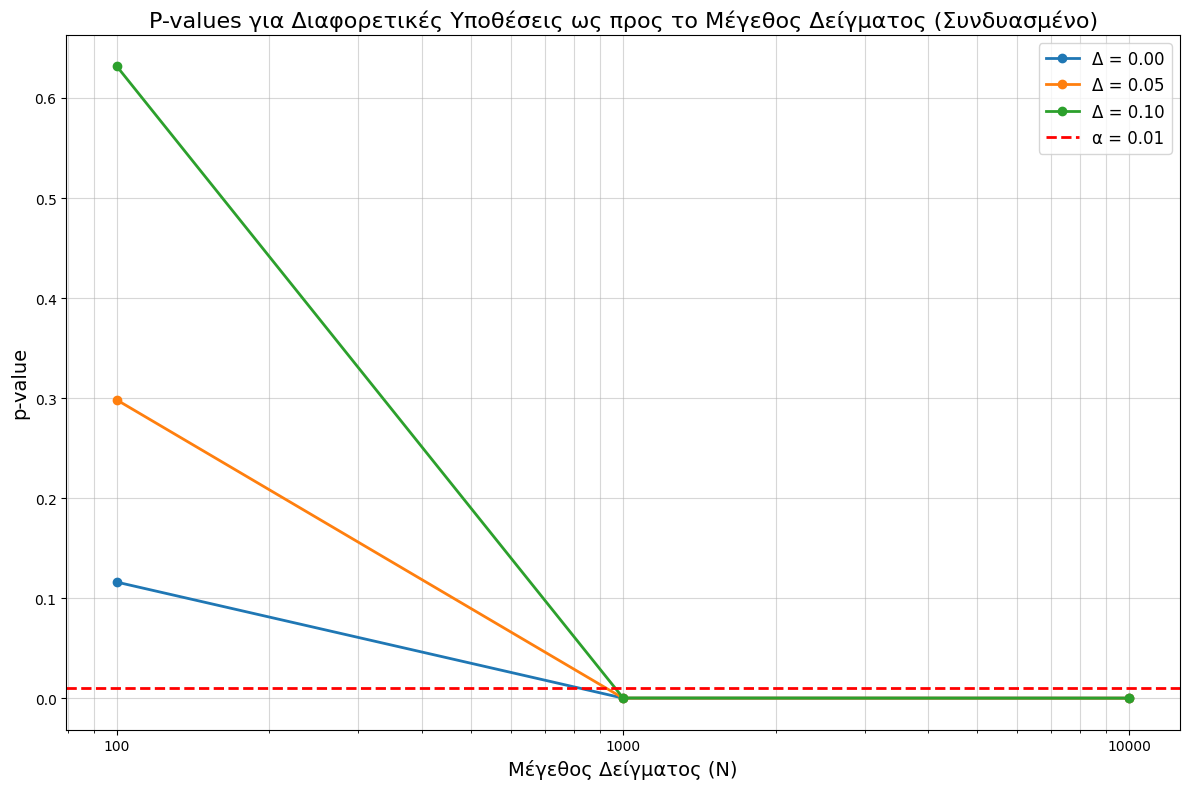

In [6]:
#cell 6
# Οπτικοποίηση των συνδυασμένων αποτελεσμάτων p-value
logging.info("Έναρξη οπτικοποίησης συνδυασμένων τάσεων p-value...")
plt.figure(figsize=(12, 8)) # Μέγεθος γραφήματος

# Σχεδίαση p-values για διαφορετικά δέλτα ως προς τα μεγέθη δείγματος
for i, delta_plot in enumerate(CONFIG['DELTAS']):
    p_vals_plot = []
    sample_sizes_for_plot = [] 
    for n_plot in CONFIG['SAMPLE_SIZES']:
        # Έλεγχος αν υπάρχουν αποτελέσματα για το τρέχον N και το τρέχον delta index
        if n_plot in results and results.get(n_plot, {}).get('p_values') and len(results[n_plot]['p_values']) > i:
            p_vals_plot.append(results[n_plot]['p_values'][i])
            sample_sizes_for_plot.append(n_plot)
        else:
            logging.warning(f"Δεδομένα p-value λείπουν για N={n_plot}, delta index={i} στο συνδυασμένο γράφημα.")
            # Μπορούμε να προσθέσουμε np.nan για να διατηρήσουμε τη συνέχεια στον άξονα x αν κάποιο Ν λείπει
            # αλλά η γραμμή θα διακοπεί. Για τώρα, απλά παραλείπουμε το σημείο.
    
    if p_vals_plot: # Σχεδίαση μόνο αν υπάρχουν δεδομένα για αυτή τη γραμμή
        plt.plot(sample_sizes_for_plot, p_vals_plot, marker='o', linestyle='-', linewidth=2, label=f'Δ = {delta_plot:.2f}')

# Οριζόντια γραμμή για το όριο σημαντικότητας alpha
plt.axhline(y=CONFIG['P_VALUE_THRESHOLD'], color='r', linestyle='--', linewidth=2, label=f'α = {CONFIG["P_VALUE_THRESHOLD"]}')

plt.xscale('log') # Λογαριθμική κλίμακα για τον άξονα Χ
plt.xticks(CONFIG['SAMPLE_SIZES'], labels=[str(n) for n in CONFIG['SAMPLE_SIZES']]) # Εμφάνιση όλων των τιμών Ν ως ticks
plt.xlabel('Μέγεθος Δείγματος (N)', fontsize=14)
plt.ylabel('p-value', fontsize=14)
plt.title('P-values για Διαφορετικές Υποθέσεις ως προς το Μέγεθος Δείγματος (Συνδυασμένο)', fontsize=16)
plt.grid(True, which="both", ls="-", alpha=0.5) # Πλέγμα για καλύτερη ανάγνωση
plt.legend(fontsize=12)
plt.tight_layout() # Βελτιστοποίηση διάταξης

# Αποθήκευση γραφήματος
try:
    plt.savefig(CONFIG["OUTPUT_PLOT_PVAL_COMBINED"], dpi=300)
    logging.info(f"Συνδυασμένο γράφημα P-value αποθηκεύτηκε στο {CONFIG['OUTPUT_PLOT_PVAL_COMBINED']}")
except Exception as e:
    logging.error(f"Αποτυχία αποθήκευσης συνδυασμένου γραφήματος p-value: {e}")
plt.show()
logging.info("Οπτικοποίηση συνδυασμένων τάσεων p-value ολοκληρώθηκε.")

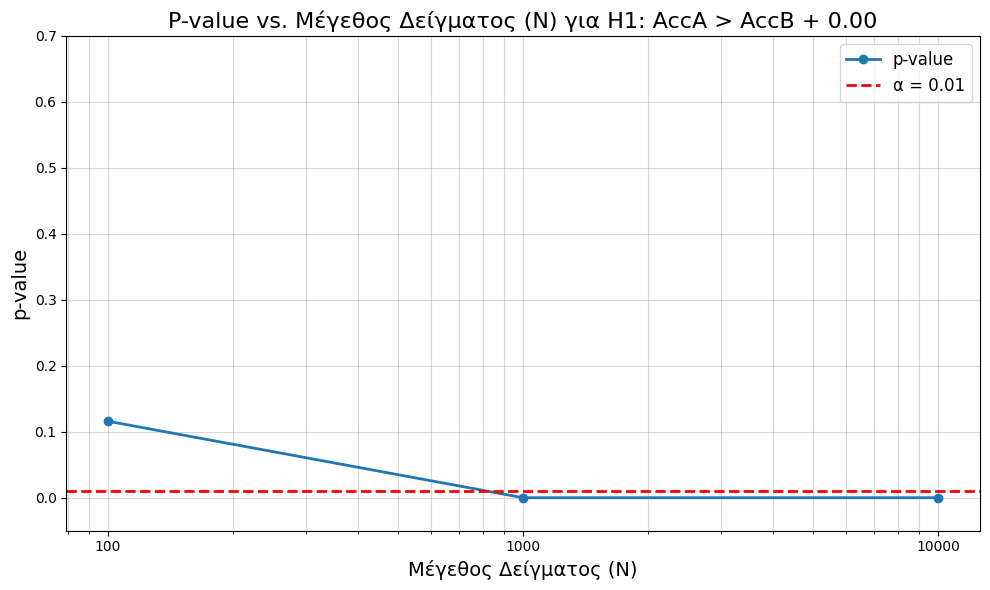

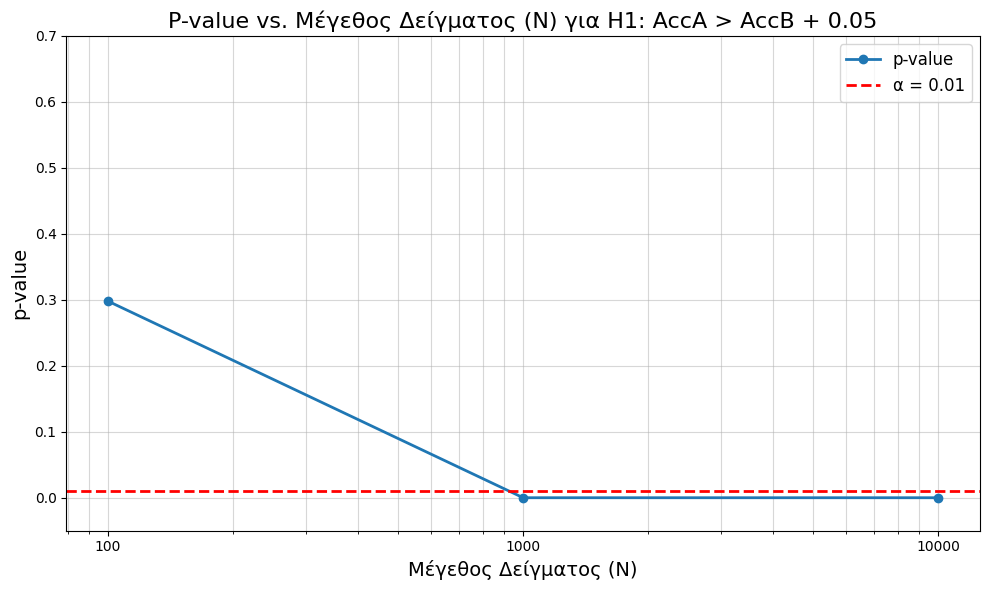

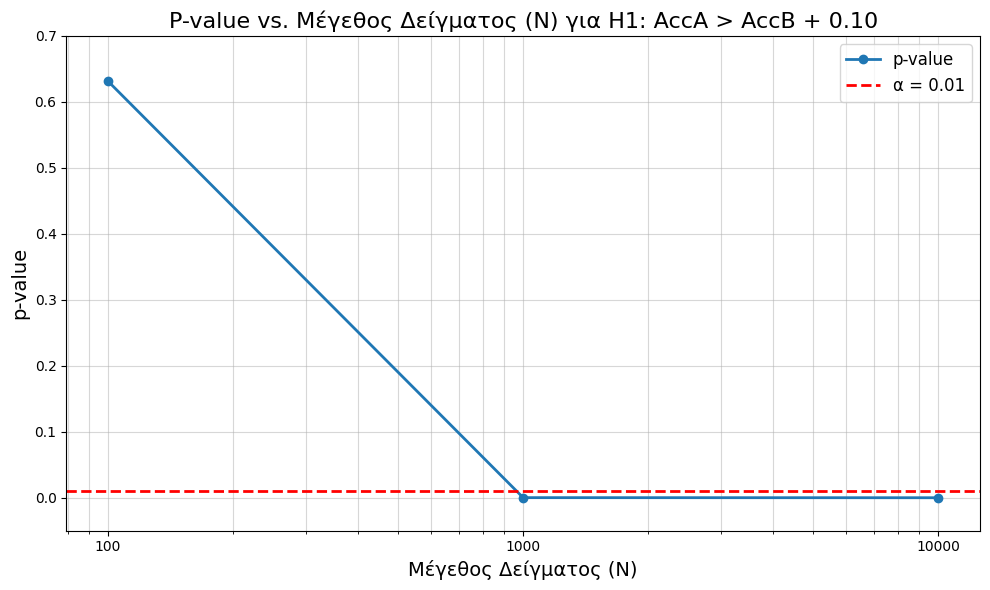

In [7]:
# cell 6a
# Οπτικοποίηση Τάσεων P-value (Ξεχωριστό γράφημα για κάθε δέλτα)
logging.info("Έναρξη οπτικοποίησης τάσεων p-value (ξεχωριστά γραφήματα)...")

if 'results' in locals() and isinstance(results, dict):
    for i_delta, delta_val_plot in enumerate(CONFIG['DELTAS']):
        plt.figure(figsize=(10, 6))
        
        p_vals_for_delta = []
        valid_sample_sizes_for_plot = []
        
        for n_val_plot in CONFIG['SAMPLE_SIZES']:
            if n_val_plot in results and results.get(n_val_plot, {}).get('p_values') and len(results[n_val_plot]['p_values']) > i_delta:
                p_vals_for_delta.append(results[n_val_plot]['p_values'][i_delta])
                valid_sample_sizes_for_plot.append(n_val_plot)
            else:
                logging.warning(f"Δεδομένα λείπουν για N={n_val_plot}, delta={delta_val_plot} στο γράφημα τάσης p-value.")

        if not p_vals_for_delta:
            logging.warning(f"Δεν βρέθηκαν p-values για delta={delta_val_plot} προς σχεδίαση.")
            plt.close() 
            continue

        plt.plot(valid_sample_sizes_for_plot, p_vals_for_delta, marker='o', linestyle='-', linewidth=2, label=f'p-value')
        plt.axhline(y=CONFIG['P_VALUE_THRESHOLD'], color='r', linestyle='--', linewidth=2, label=f'α = {CONFIG["P_VALUE_THRESHOLD"]}')
        
        plt.xscale('log')
        plt.xticks(CONFIG['SAMPLE_SIZES'], labels=[str(n) for n in CONFIG['SAMPLE_SIZES']])
        plt.xlabel('Μέγεθος Δείγματος (N)', fontsize=14)
        plt.ylabel('p-value', fontsize=14)
        plt.title(f'P-value vs. Μέγεθος Δείγματος (N) για H1: AccA > AccB + {delta_val_plot:.2f}', fontsize=16)
        plt.grid(True, which="both", ls="-", alpha=0.5)
        plt.legend(fontsize=12)
        min_val_y_sep = -0.05
        max_val_y_sep = max(0.7, np.nanmax(p_vals_for_delta) * 1.1 if p_vals_for_delta and not all(np.isnan(p_vals_for_delta)) else 0.7) 
        plt.ylim(bottom=min_val_y_sep, top=max_val_y_sep) 
        plt.tight_layout()
        
        plot_filename_pval_sep = f"{CONFIG['OUTPUT_PLOT_PVAL_DELTA_PREFIX']}{str(delta_val_plot).replace('.', '_')}.png"
        try:
            plt.savefig(plot_filename_pval_sep, dpi=300)
            logging.info(f"Γράφημα τάσης P-value για delta={delta_val_plot} αποθηκεύτηκε στο {plot_filename_pval_sep}")
        except Exception as e:
            logging.error(f"Αποτυχία αποθήκευσης γραφήματος τάσης p-value για delta={delta_val_plot}: {e}")
        plt.show()
else:
    logging.warning("Το λεξικό results δεν βρέθηκε ή είναι άδειο. Παράλειψη γραφημάτων τάσεων p-value (ξεχωριστά).")

logging.info("Οπτικοποίηση τάσεων p-value (ξεχωριστά γραφήματα) ολοκληρώθηκε.")

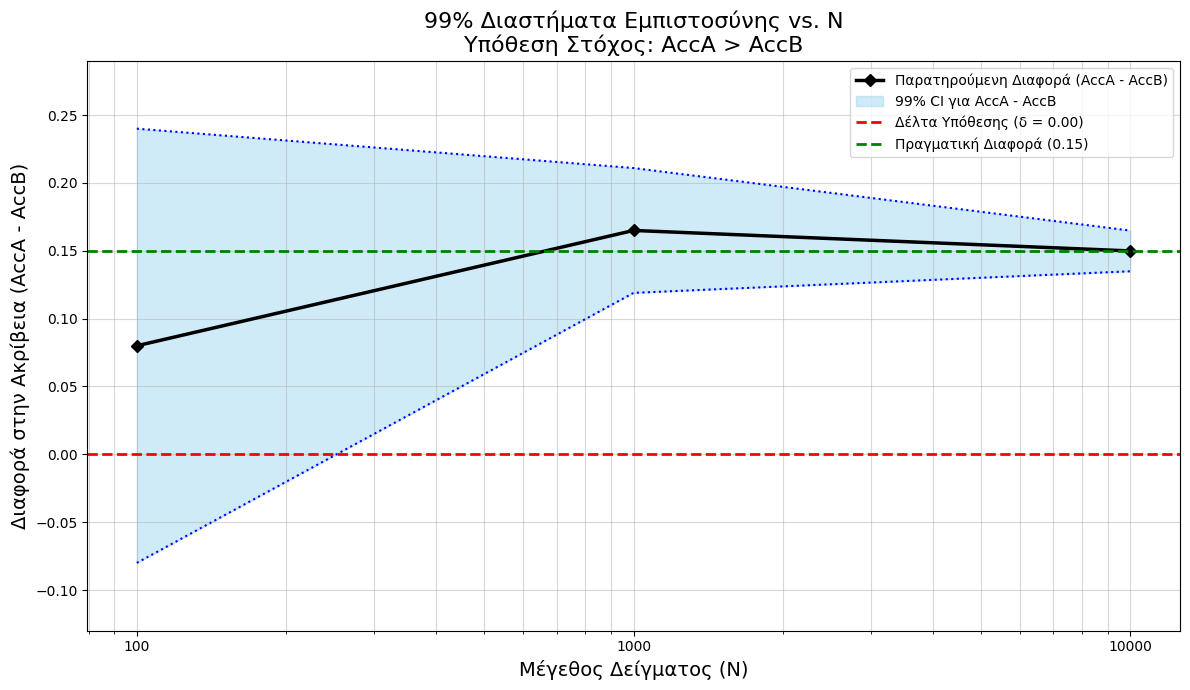

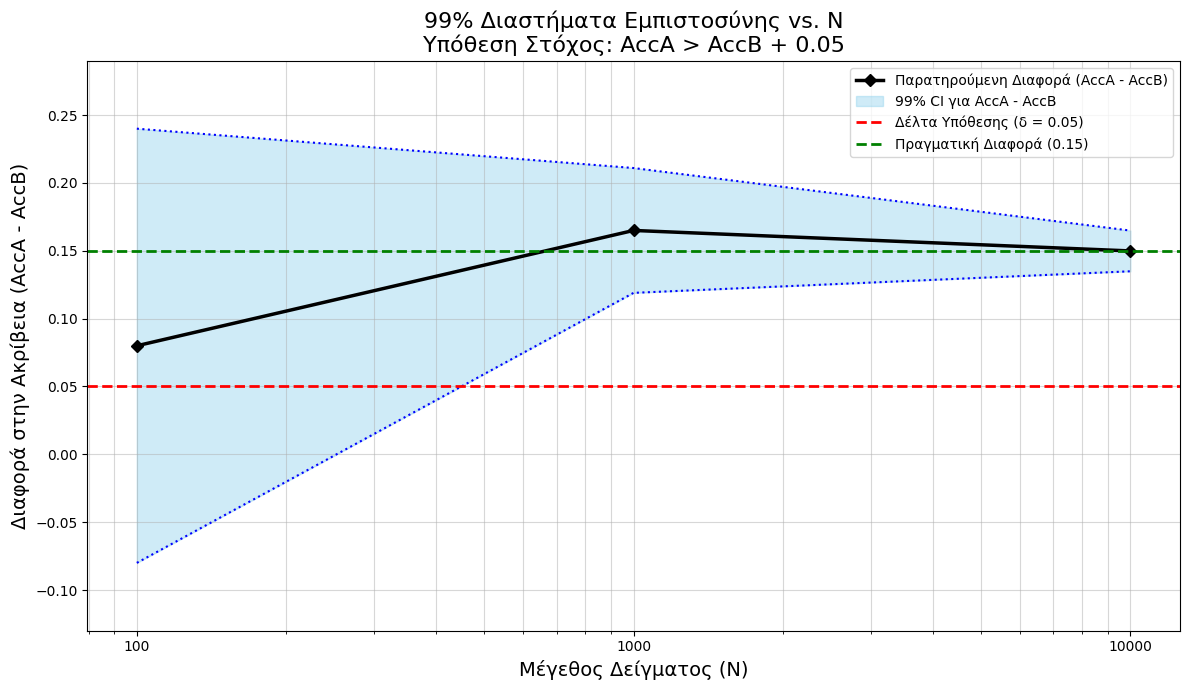

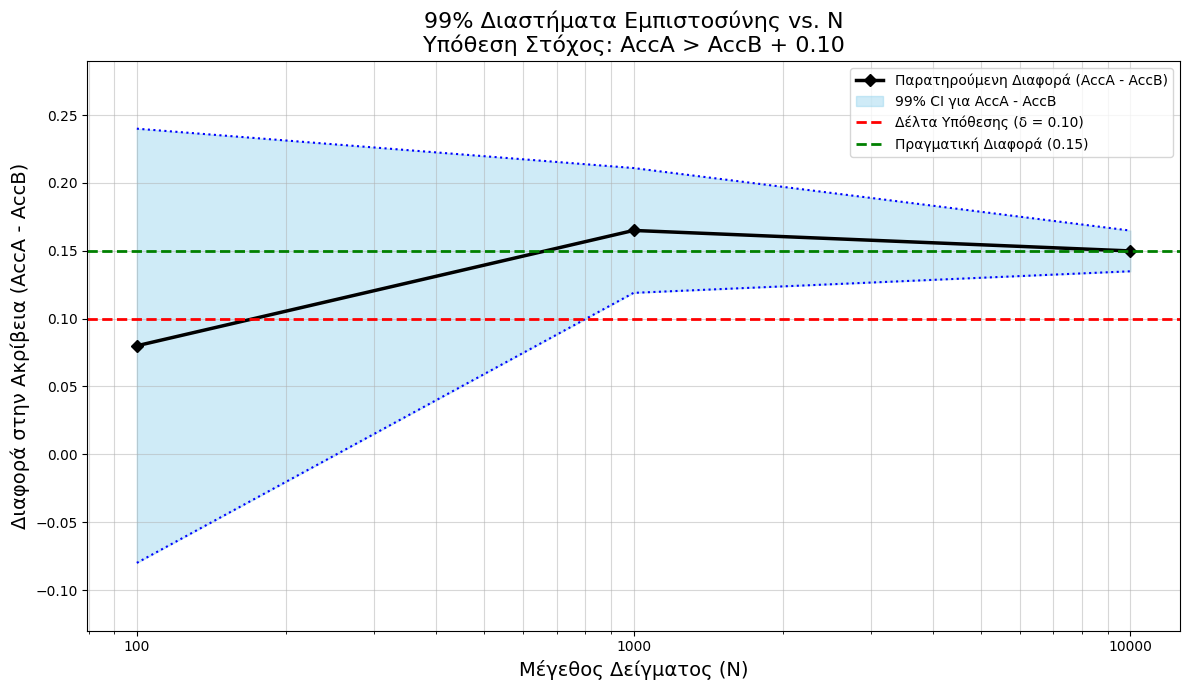

In [8]:
# cell 6b
# Οπτικοποίηση Τάσεων Διαστημάτων Εμπιστοσύνης
logging.info("Έναρξη οπτικοποίησης τάσεων Διαστημάτων Εμπιστοσύνης...")

if 'results' in locals() and isinstance(results, dict):
    true_diff_acc = CONFIG["ACC_A_TRUE"] - CONFIG["ACC_B_TRUE"]
    
    for i_delta_ci, delta_val_ci in enumerate(CONFIG['DELTAS']):
        plt.figure(figsize=(12, 7))
        
        observed_diffs_ci = []
        ci_lowers = []
        ci_uppers = []
        valid_sample_sizes_ci_plot = []

        for n_ci in CONFIG['SAMPLE_SIZES']:
            if n_ci in results and 'observed_diff' in results[n_ci] and 'confidence_interval' in results[n_ci]:
                observed_diffs_ci.append(results[n_ci]['observed_diff'])
                ci_lowers.append(results[n_ci]['confidence_interval'][0])
                ci_uppers.append(results[n_ci]['confidence_interval'][1])
                valid_sample_sizes_ci_plot.append(n_ci)
            else:
                logging.warning(f"Δεδομένα λείπουν για N={n_ci} στο γράφημα CI για delta={delta_val_ci}.")
        
        if not observed_diffs_ci:
            logging.warning(f"Δεν υπάρχουν δεδομένα για σχεδίαση των CI trends για delta={delta_val_ci}.")
            plt.close()
            continue

        # Σχεδίαση Παρατηρούμενης Διαφοράς
        plt.plot(valid_sample_sizes_ci_plot, observed_diffs_ci, marker='D', linestyle='-', linewidth=2.5,
                 color='black', label='Παρατηρούμενη Διαφορά (AccA - AccB)')

        # Σχεδίαση Διαστημάτων Εμπιστοσύνης
        plt.fill_between(valid_sample_sizes_ci_plot, ci_lowers, ci_uppers,
                         color='skyblue', alpha=0.4, label=f'{int(CONFIG["CONFIDENCE_LEVEL"]*100)}% CI για AccA - AccB')
        plt.plot(valid_sample_sizes_ci_plot, ci_lowers, linestyle=':', linewidth=1.5, color='blue', label='_nolegend_') # _nolegend_ για να μην εμφανιστεί διπλή ετικέτα
        plt.plot(valid_sample_sizes_ci_plot, ci_uppers, linestyle=':', linewidth=1.5, color='blue', label='_nolegend_')

        # Γραμμή Δέλτα Υπόθεσης
        plt.axhline(y=delta_val_ci, color='red', linestyle='--', lw=2,
                    label=f'Δέλτα Υπόθεσης (δ = {delta_val_ci:.2f})')
        
        # Γραμμή Πραγματικής Διαφοράς
        plt.axhline(y=true_diff_acc, color='green', linestyle='--', lw=2,
                    label=f'Πραγματική Διαφορά ({true_diff_acc:.2f})')

        plt.xscale('log')
        plt.xticks(CONFIG['SAMPLE_SIZES'], labels=[str(n) for n in CONFIG['SAMPLE_SIZES']])
        plt.xlabel('Μέγεθος Δείγματος (N)', fontsize=14)
        plt.ylabel('Διαφορά στην Ακρίβεια (AccA - AccB)', fontsize=14)
        hypothesis_desc_ci = f"AccA > AccB + {delta_val_ci:.2f}" if delta_val_ci > 0 else "AccA > AccB"
        plt.title(f'{int(CONFIG["CONFIDENCE_LEVEL"]*100)}% Διαστήματα Εμπιστοσύνης vs. N\nΥπόθεση Στόχος: {hypothesis_desc_ci}', fontsize=16)
        
        all_vals_for_ylim_ci = observed_diffs_ci + ci_lowers + ci_uppers + [delta_val_ci, true_diff_acc]
        if all_vals_for_ylim_ci: 
            min_ylim_ci = min(all_vals_for_ylim_ci) - 0.05
            max_ylim_ci = max(all_vals_for_ylim_ci) + 0.05
            plt.ylim(min_ylim_ci, max_ylim_ci)
        
        plt.grid(True, which="both", ls="-", alpha=0.5)
        plt.legend(fontsize=10, loc='best')
        plt.tight_layout()
        
        plot_filename_ci_sep = f"{CONFIG['OUTPUT_PLOT_CI_DELTA_PREFIX']}{str(delta_val_ci).replace('.', '_')}.png"
        try:
            plt.savefig(plot_filename_ci_sep, dpi=300)
            logging.info(f"Γράφημα τάσης CI για delta={delta_val_ci} αποθηκεύτηκε στο {plot_filename_ci_sep}")
        except Exception as e:
            logging.error(f"Αποτυχία αποθήκευσης γραφήματος CI για delta={delta_val_ci}: {e}")
        plt.show()
else:
    logging.warning("Το λεξικό results δεν βρέθηκε ή είναι άδειο. Παράλειψη γραφημάτων CI.")
    
logging.info("Οπτικοποίηση τάσεων Διαστημάτων Εμπιστοσύνης ολοκληρώθηκε.")

Bootstrap επαναλήψεις:   0%|          | 0/10000 [00:00<?, ?it/s]

/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


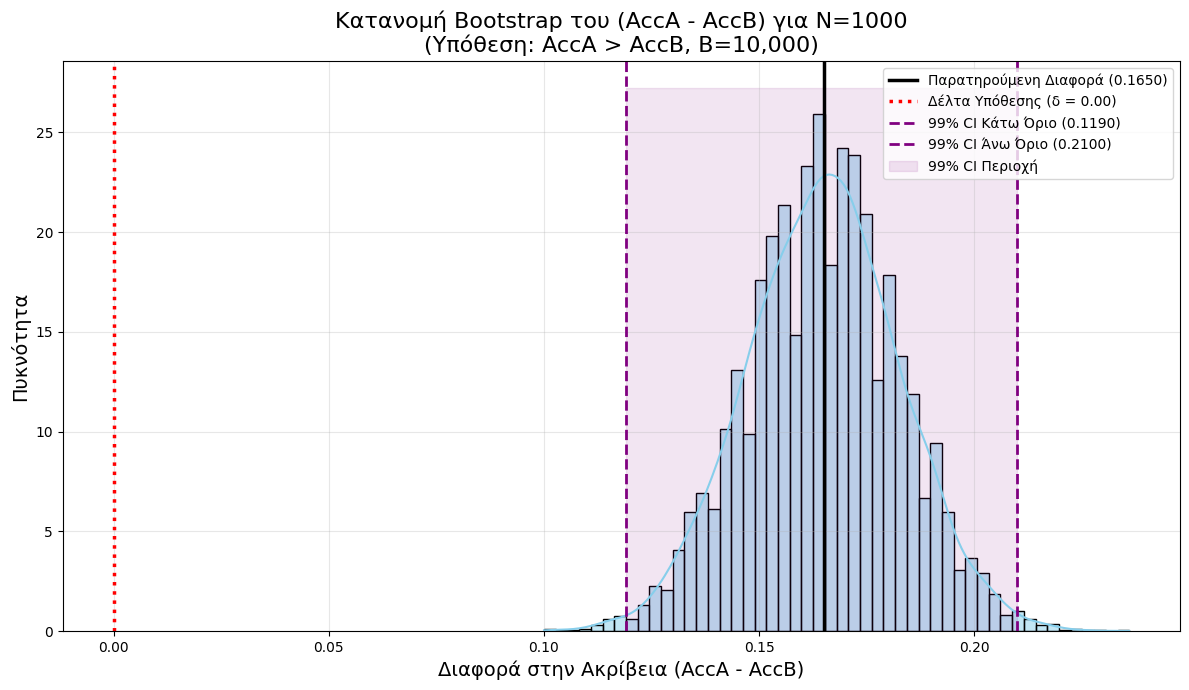

In [9]:
# cell 6c
# Οπτικοποίηση μιας Αντιπροσωπευτικής Κατανομής Bootstrap
logging.info("Έναρξη οπτικοποίησης Κατανομής Bootstrap...")

N_vis_dist = 1000  # Αντιπροσωπευτικό Ν
delta_vis_dist = 0.0 # Αντιπροσωπευτικό δέλτα

if N_vis_dist in results and isinstance(results, dict):
    simulation_seed_dist = CONFIG["RANDOM_SEED"] + N_vis_dist
    vis_A_outcomes, vis_B_outcomes = generate_predictions(
        N_vis_dist, 
        CONFIG["ACC_A_TRUE"], 
        CONFIG["ACC_B_TRUE"],
        seed=simulation_seed_dist
    )
    vis_obs_diff_dist = np.mean(vis_A_outcomes) - np.mean(vis_B_outcomes)

    B_vis_plot = CONFIG["B_REPLICATIONS_VIS_DIST"] 
    bootstrap_seed_dist_plot = CONFIG["RANDOM_SEED"] + N_vis_dist + sum(CONFIG["SAMPLE_SIZES"]) + 1 

    # Παίρνουμε την κατανομή και το CI από τη συνάρτησή μας
    # Το p-value εδώ δεν μας ενδιαφέρει άμεσα για το γράφημα, αλλά το υπολογίζουμε
    _, ci_vis_plot_dist, dist_for_plot = paired_bootstrap_test(
        vis_A_outcomes, 
        vis_B_outcomes, 
        B_vis_plot, 
        [delta_vis_dist], 
        confidence_level=CONFIG["CONFIDENCE_LEVEL"],
        seed=bootstrap_seed_dist_plot,
        return_distribution=True
    )

    if dist_for_plot is not None and dist_for_plot.size > 0 :
        plt.figure(figsize=(12, 7))
        sns.histplot(dist_for_plot, bins=50, kde=True, stat="density", color='skyblue', edgecolor='black')
        
        plt.axvline(vis_obs_diff_dist, color='black', linestyle='-', linewidth=2.5, 
                    label=f'Παρατηρούμενη Διαφορά ({vis_obs_diff_dist:.4f})')
        plt.axvline(delta_vis_dist, color='red', linestyle=':', linewidth=2.5, 
                    label=f'Δέλτα Υπόθεσης (δ = {delta_vis_dist:.2f})')
        
        plt.axvline(ci_vis_plot_dist[0], color='purple', linestyle='--', linewidth=2, 
                    label=f'{int(CONFIG["CONFIDENCE_LEVEL"]*100)}% CI Κάτω Όριο ({ci_vis_plot_dist[0]:.4f})')
        plt.axvline(ci_vis_plot_dist[1], color='purple', linestyle='--', linewidth=2, 
                    label=f'{int(CONFIG["CONFIDENCE_LEVEL"]*100)}% CI Άνω Όριο ({ci_vis_plot_dist[1]:.4f})')
        plt.fill_betweenx(plt.ylim(), ci_vis_plot_dist[0], ci_vis_plot_dist[1], color='purple', alpha=0.1,
                          label=f'{int(CONFIG["CONFIDENCE_LEVEL"]*100)}% CI Περιοχή')

        hypothesis_desc_dist_plot = f"AccA > AccB + {delta_vis_dist:.2f}" if delta_vis_dist > 0 else "AccA > AccB"
        plt.title(f'Κατανομή Bootstrap του (AccA - AccB) για N={N_vis_dist}\n(Υπόθεση: {hypothesis_desc_dist_plot}, B={B_vis_plot:,})', fontsize=16)
        plt.xlabel('Διαφορά στην Ακρίβεια (AccA - AccB)', fontsize=14)
        plt.ylabel('Πυκνότητα', fontsize=14)
        plt.legend(fontsize=10, loc='best')
        plt.grid(True, alpha=0.3)
        plt.tight_layout()

        plot_filename_dist_final = f"{CONFIG['OUTPUT_PLOT_DIST_PREFIX']}{N_vis_dist}_delta_{str(delta_vis_dist).replace('.', '_')}.png"
        try:
            plt.savefig(plot_filename_dist_final, dpi=300)
            logging.info(f"Γράφημα κατανομής Bootstrap αποθηκεύτηκε στο {plot_filename_dist_final}")
        except Exception as e:
            logging.error(f"Αποτυχία αποθήκευσης γραφήματος κατανομής bootstrap: {e}")
        plt.show()
    else:
        logging.warning(f"Δεν παρήχθη κατανομή bootstrap για N={N_vis_dist}, delta={delta_vis_dist}.")
else:
    logging.warning(f"Αποτελέσματα για N={N_vis_dist} δεν βρέθηκαν. Παράλειψη γραφήματος κατανομής bootstrap.")
    
logging.info("Οπτικοποίηση Κατανομής Bootstrap ολοκληρώθηκε.")

In [10]:
#cell 7
# Δημιουργία πίνακα σύνοψης και αποθήκευση σε CSV
logging.info("Δημιουργία και αποθήκευση λεπτομερούς πίνακα σύνοψης...")
data_for_df_detailed = []
if 'results' in locals() and isinstance(results, dict):
    for n_df_detailed in CONFIG["SAMPLE_SIZES"]:
        if n_df_detailed in results:
            res_n = results[n_df_detailed] # Αποτελέσματα για το τρέχον Ν
            # Έλεγχος ότι τα 'p_values' και 'confidence_interval' υπάρχουν και έχουν το σωστό μήκος
            if 'p_values' in res_n and 'confidence_interval' in res_n and \
               len(res_n['p_values']) == len(CONFIG['DELTAS']) and \
               isinstance(res_n['confidence_interval'], tuple) and len(res_n['confidence_interval']) == 2:
                
                for i_df, delta_df_detailed in enumerate(res_n['delta_values']):
                    data_for_df_detailed.append({
                        'Μέγεθος Δείγματος (N)': n_df_detailed,
                        'Δέλτα (δ)': delta_df_detailed,
                        'Acc_A (παρατηρ.)': f"{res_n['acc_a']:.4f}",
                        'Acc_B (παρατηρ.)': f"{res_n['acc_b']:.4f}",
                        'Acc_A - Acc_B (παρατηρ.)': f"{res_n['observed_diff']:.4f}",
                        'p-value': f"{res_n['p_values'][i_df]:.6f}",
                        f'Απόρριψη H0 (α={CONFIG["P_VALUE_THRESHOLD"]})': 'Ναι' if res_n['p_values'][i_df] < CONFIG["P_VALUE_THRESHOLD"] else 'Όχι',
                        f'{int(CONFIG["CONFIDENCE_LEVEL"]*100)}% CI Κάτω Όριο': f"{res_n['confidence_interval'][0]:.4f}",
                        f'{int(CONFIG["CONFIDENCE_LEVEL"]*100)}% CI Άνω Όριο': f"{res_n['confidence_interval'][1]:.4f}"
                    })
            else:
                logging.warning(f"Ελλιπή δεδομένα p-values ή confidence_interval για N = {n_df_detailed} κατά τη δημιουργία του DataFrame.")
        else:
            logging.warning(f"Δεν βρέθηκαν αποτελέσματα για N = {n_df_detailed} κατά τη δημιουργία του DataFrame.")

if data_for_df_detailed:
    summary_df_final = pd.DataFrame(data_for_df_detailed)
    print("\n===== ΛΕΠΤΟΜΕΡΗΣ ΠΙΝΑΚΑΣ ΣΥΝΟΨΗΣ ΑΠΟΤΕΛΕΣΜΑΤΩΝ (με CIs) =====")
    with pd.option_context('display.max_rows', None, 'display.max_columns', None, 'display.width', 120): # Αύξηση πλάτους για καλύτερη εμφάνιση
        print(summary_df_final.to_string(index=False))

    try:
        summary_df_final.to_csv(CONFIG["OUTPUT_CSV_FILE"], index=False, encoding='utf-8')
        logging.info(f"Λεπτομερής πίνακας σύνοψης αποθηκεύτηκε στο {CONFIG['OUTPUT_CSV_FILE']}")
    except Exception as e:
        logging.error(f"Αποτυχία αποθήκευσης λεπτομερούς πίνακα σύνοψης CSV: {e}")
else:
    logging.warning("Δεν υπάρχουν δεδομένα για τη δημιουργία του λεπτομερούς πίνακα σύνοψης.")

logging.info("Δημιουργία και αποθήκευση λεπτομερούς πίνακα σύνοψης ολοκληρώθηκε.")


===== ΛΕΠΤΟΜΕΡΗΣ ΠΙΝΑΚΑΣ ΣΥΝΟΨΗΣ ΑΠΟΤΕΛΕΣΜΑΤΩΝ (με CIs) =====
 Μέγεθος Δείγματος (N)  Δέλτα (δ) Acc_A (παρατηρ.) Acc_B (παρατηρ.) Acc_A - Acc_B (παρατηρ.)  p-value Απόρριψη H0 (α=0.01) 99% CI Κάτω Όριο 99% CI Άνω Όριο
                   100       0.00           0.7900           0.7100                   0.0800 0.115968                  Όχι          -0.0800          0.2400
                   100       0.05           0.7900           0.7100                   0.0800 0.298047                  Όχι          -0.0800          0.2400
                   100       0.10           0.7900           0.7100                   0.0800 0.631546                  Όχι          -0.0800          0.2400
                  1000       0.00           0.8630           0.6980                   0.1650 0.000000                  Ναι           0.1190          0.2110
                  1000       0.05           0.8630           0.6980                   0.1650 0.000000                  Ναι           0.1190          0.2110
 

In [11]:
#cell 8
# Προαιρετικό: Σύγκριση με υπάρχουσα υλοποίηση (π.χ. mlxtend)
logging.info("Παράλειψη σύγκρισης με mlxtend (προαιρετικό cell).")
"""
try:
    from mlxtend.evaluate import bootstrap_point632_score
    logging.info("\\nΣύγκριση με υλοποίηση mlxtend (αν είναι διαθέσιμη):")
    for n_mlxtend in CONFIG["SAMPLE_SIZES"]:
        logging.info(f"\\nΜέγεθος δείγματος: N = {n_mlxtend}")
        comp_seed_mlxtend = CONFIG["RANDOM_SEED"] + n_mlxtend + 200000
        pred_a_mlxtend, pred_b_mlxtend = generate_predictions(
            n_mlxtend, CONFIG["ACC_A_TRUE"], CONFIG["ACC_B_TRUE"], seed=comp_seed_mlxtend
        )
        acc_a_actual_mlxtend = np.mean(pred_a_mlxtend)
        acc_b_actual_mlxtend = np.mean(pred_b_mlxtend)
        logging.info(f"Παρατηρούμενες για σύγκριση - Acc_A: {acc_a_actual_mlxtend:.4f}, Acc_B: {acc_b_actual_mlxtend:.4f}")
        logging.warning("Σημείωση: Η mlxtend δεν έχει ακριβές ισοδύναμο του paired bootstrap test για p-values διαφοράς.")
        logging.warning("Αυτό το τμήμα θα χρειαζόταν μια συγκεκριμένη συνάρτηση της mlxtend που ταιριάζει.")
except ImportError:
    logging.warning("\\nΗ βιβλιοθήκη mlxtend δεν είναι διαθέσιμη για σύγκριση.")
"""

'\ntry:\n    from mlxtend.evaluate import bootstrap_point632_score\n    logging.info("\\nΣύγκριση με υλοποίηση mlxtend (αν είναι διαθέσιμη):")\n    for n_mlxtend in CONFIG["SAMPLE_SIZES"]:\n        logging.info(f"\\nΜέγεθος δείγματος: N = {n_mlxtend}")\n        comp_seed_mlxtend = CONFIG["RANDOM_SEED"] + n_mlxtend + 200000\n        pred_a_mlxtend, pred_b_mlxtend = generate_predictions(\n            n_mlxtend, CONFIG["ACC_A_TRUE"], CONFIG["ACC_B_TRUE"], seed=comp_seed_mlxtend\n        )\n        acc_a_actual_mlxtend = np.mean(pred_a_mlxtend)\n        acc_b_actual_mlxtend = np.mean(pred_b_mlxtend)\n        logging.info(f"Παρατηρούμενες για σύγκριση - Acc_A: {acc_a_actual_mlxtend:.4f}, Acc_B: {acc_b_actual_mlxtend:.4f}")\n        logging.warning("Σημείωση: Η mlxtend δεν έχει ακριβές ισοδύναμο του paired bootstrap test για p-values διαφοράς.")\n        logging.warning("Αυτό το τμήμα θα χρειαζόταν μια συγκεκριμένη συνάρτηση της mlxtend που ταιριάζει.")\nexcept ImportError:\n    logging.warn

In [12]:
# cell 9 (Final Recommended Version for SciPy Comparison)
# Σύγκριση με την υλοποίηση bootstrap της βιβλιοθήκης SciPy
try:
    from scipy.stats import bootstrap as scipy_bootstrap
    
    logging.info("===== ΕΝΑΡΞΗ ΣΥΓΚΡΙΣΗΣ ΜΕ SCIPY.STATS.BOOTSTRAP =====")

    def scipy_paired_bootstrap_metrics(pred_a_scipy, pred_b_scipy, num_bootstraps_scipy, deltas_scipy, 
                                       confidence_level_scipy, method_scipy='BCa', seed_scipy=None):
        """
        Εκτελεί paired bootstrap test χρησιμοποιώντας τη scipy.stats.bootstrap για να πάρει την κατανομή
        των διαφορών και τα διαστήματα εμπιστοσύνης. Στη συνέχεια, υπολογίζει τα p-values
        για την υπόθεση H1: Acc_A - Acc_B > delta.
        """
        if len(pred_a_scipy) == 0:
            logging.warning("scipy_paired_bootstrap_metrics: Οι πίνακες εισόδου είναι κενοί.")
            return [np.nan] * len(deltas_scipy), (np.nan, np.nan), np.array([])

        # Τα δεδομένα για τη scipy.stats.bootstrap πρέπει να είναι μια ακολουθία δειγμάτων.
        # Για ζευγαρωτές διαφορές, περνάμε τον πίνακα των διαφορών.
        paired_differences = pred_a_scipy.astype(float) - pred_b_scipy.astype(float)
        data_for_scipy = (paired_differences,) # Πρέπει να είναι ακολουθία (tuple of arrays)

        # Η scipy.bootstrap χρειάζεται μια συνάρτηση στατιστικού (εδώ, ο μέσος όρος των διαφορών)
        def mean_statistic(data_axis, axis=None): 
            return np.mean(data_axis, axis=axis)

        # Χρήση του νέου API της NumPy για τη γεννήτρια τυχαίων αριθμών για τη SciPy
        rng_scipy = np.random.default_rng(seed_scipy) if seed_scipy is not None else np.random.default_rng()

        # Παραγωγή της bootstrap κατανομής του μέσου όρου των διαφορών
        res = scipy_bootstrap(
            data_for_scipy,
            statistic=mean_statistic,
            n_resamples=num_bootstraps_scipy,
            confidence_level=confidence_level_scipy,
            method=method_scipy, # 'BCa' (προτεινόμενο) ή 'percentile' ή 'basic'
            random_state=rng_scipy,
        )
        
        bootstrap_diff_dist_scipy = res.bootstrap_distribution
        
        p_values_scipy_list = []
        if bootstrap_diff_dist_scipy is not None and len(bootstrap_diff_dist_scipy) > 0:
            for delta_val_scipy in deltas_scipy:
                # H0: Πραγματική_Διαφορά <= delta  => H1: Πραγματική_Διαφορά > delta
                # p-value είναι P(bootstrap_διαφορά <= delta | H0 ισχύει)
                p_value = np.sum(bootstrap_diff_dist_scipy <= delta_val_scipy) / len(bootstrap_diff_dist_scipy)
                p_values_scipy_list.append(p_value)
        else:
            logging.error("Η scipy.stats.bootstrap δεν επέστρεψε έγκυρη κατανομή.")
            p_values_scipy_list = [np.nan] * len(deltas_scipy)
            
        ci_scipy = (res.confidence_interval.low, res.confidence_interval.high)
        
        logging.debug(f"scipy_paired_bootstrap_metrics ολοκληρώθηκε. Seed: {seed_scipy}, Μέθοδος CI: {method_scipy}.")
        return p_values_scipy_list, ci_scipy, bootstrap_diff_dist_scipy # Επιστρέφουμε και την κατανομή για πιθανή χρήση

    print("\n===== ΣΥΓΚΡΙΣΗ P-VALUES & CIs (Δική μας Υλοπ. vs. Βασισμένη σε SciPy) =====")
    for n_comp in CONFIG["SAMPLE_SIZES"]:
        logging.info(f"--- Σύγκριση για N = {n_comp} ---")
        
        # Παραγωγή νέων δεδομένων για αυτή τη συγκεκριμένη σύγκριση
        # Χρησιμοποιούμε ένα ξεχωριστό, αλλά σταθερό, seed για κάθε Ν εδώ
        comp_data_seed = CONFIG["RANDOM_SEED"] + n_comp + 700000 
        pred_a_comp_run, pred_b_comp_run = generate_predictions(
            n_comp, CONFIG["ACC_A_TRUE"], CONFIG["ACC_B_TRUE"], seed=comp_data_seed
        )
        
        observed_acc_a_comp = np.mean(pred_a_comp_run)
        observed_acc_b_comp = np.mean(pred_b_comp_run)
        obs_diff_comp = observed_acc_a_comp - observed_acc_b_comp
        logging.info(f"Παρατηρούμενη ακρίβεια για σύγκριση - N={n_comp} - Ταξ. A: {observed_acc_a_comp:.4f}, Ταξ. B: {observed_acc_b_comp:.4f}, Διαφορά: {obs_diff_comp:.4f}")
        
        B_compare_val = CONFIG["B_REPLICATIONS_COMPARE"] # π.χ., 10,000 για ταχύτητα σύγκρισης
        logging.info(f"Εκτέλεση σύγκρισης με {B_compare_val:,} bootstrap δείγματα για N={n_comp}...")
        
        # Χρησιμοποιούμε το ΙΔΙΟ seed και για τις δύο μεθόδους bootstrap για άμεση σύγκριση των αλγορίθμων τους
        comparison_bootstrap_seed = CONFIG["RANDOM_SEED"] + n_comp + 800000 

        # Δική μας υλοποίηση
        logging.info(f"Εκτέλεση paired_bootstrap_test (δική μας) για N={n_comp} με seed {comparison_bootstrap_seed}")
        our_p_values_comp, our_ci_comp = paired_bootstrap_test(
            pred_a_comp_run, pred_b_comp_run, B_compare_val, CONFIG["DELTAS"], 
            confidence_level=CONFIG["CONFIDENCE_LEVEL"], seed=comparison_bootstrap_seed
        )
        
        # Υλοποίηση βασισμένη στη SciPy
        scipy_method_for_ci = 'BCa' # Προτεινόμενη μέθοδος για ακρίβεια, αν και πιο αργή
        logging.info(f"Εκτέλεση scipy_paired_bootstrap_metrics για N={n_comp} με seed {comparison_bootstrap_seed} και μέθοδο CI: {scipy_method_for_ci}")
        scipy_p_values_comp, scipy_ci_comp, _ = scipy_paired_bootstrap_metrics( # Αγνοούμε την επιστρεφόμενη κατανομή εδώ
            pred_a_comp_run, pred_b_comp_run, B_compare_val, CONFIG["DELTAS"],
            confidence_level_scipy=CONFIG["CONFIDENCE_LEVEL"], 
            method_scipy=scipy_method_for_ci, 
            seed_scipy=comparison_bootstrap_seed
        )
        
        print(f"\nΣύγκριση για N = {n_comp} (B_compare={B_compare_val:,}):")
        print(f"{'Δέλτα':<10} {'P-val (Δικό μας)':<20} {'P-val (SciPy)':<20} {'Απόλ. Διαφ. P':<20} | {'CI (Δικό μας)':<22} {'CI (SciPy '+scipy_method_for_ci+')':<22}")
        print("-" * 120)
        for i, delta_val_comp in enumerate(CONFIG["DELTAS"]):
            # Έλεγχος για NaN πριν τον υπολογισμό της διαφοράς
            our_p = our_p_values_comp[i]
            scipy_p = scipy_p_values_comp[i]
            diff_p_val = abs(our_p - scipy_p) if not (np.isnan(our_p) or np.isnan(scipy_p)) else np.nan
            
            our_ci_str = f"({our_ci_comp[0]:.4f}, {our_ci_comp[1]:.4f})" if not (np.isnan(our_ci_comp[0]) or np.isnan(our_ci_comp[1])) else "(NaN, NaN)"
            scipy_ci_str = f"({scipy_ci_comp[0]:.4f}, {scipy_ci_comp[1]:.4f})" if not (np.isnan(scipy_ci_comp[0]) or np.isnan(scipy_ci_comp[1])) else "(NaN, NaN)"
            
            print(f"{delta_val_comp:<10.2f} {our_p:<20.6f} {scipy_p:<20.6f} {diff_p_val:<20.6f} | {our_ci_str:<22} {scipy_ci_str:<22}")
        logging.info(f"--- Σύγκριση για N = {n_comp} ολοκληρώθηκε ---")

except ImportError:
    logging.error("Η βιβλιοθήκη SciPy δεν είναι διαθέσιμη για σύγκριση. Εγκαταστήστε την με 'pip install scipy'.")
except Exception as e:
    logging.error(f"Παρουσιάστηκε σφάλμα κατά τη σύγκριση με SciPy: {e}", exc_info=True)

logging.info("===== ΟΛΟΚΛΗΡΩΣΗ ΣΥΓΚΡΙΣΗΣ ΜΕ SCIPY.STATS.BOOTSTRAP =====")


===== ΣΥΓΚΡΙΣΗ P-VALUES & CIs (Δική μας Υλοπ. vs. Βασισμένη σε SciPy) =====


Bootstrap επαναλήψεις:   0%|          | 0/10000 [00:00<?, ?it/s]


Σύγκριση για N = 100 (B_compare=10,000):
Δέλτα      P-val (Δικό μας)     P-val (SciPy)        Απόλ. Διαφ. P        | CI (Δικό μας)          CI (SciPy BCa)        
------------------------------------------------------------------------------------------------------------------------
0.00       0.001400             0.002100             0.000700             | (0.0200, 0.3200)       (0.0200, 0.3100)      
0.05       0.016500             0.022200             0.005700             | (0.0200, 0.3200)       (0.0200, 0.3100)      
0.10       0.120400             0.123600             0.003200             | (0.0200, 0.3200)       (0.0200, 0.3100)      


Bootstrap επαναλήψεις:   0%|          | 0/10000 [00:00<?, ?it/s]


Σύγκριση για N = 1000 (B_compare=10,000):
Δέλτα      P-val (Δικό μας)     P-val (SciPy)        Απόλ. Διαφ. P        | CI (Δικό μας)          CI (SciPy BCa)        
------------------------------------------------------------------------------------------------------------------------
0.00       0.000000             0.000000             0.000000             | (0.1280, 0.2230)       (0.1280, 0.2230)      
0.05       0.000000             0.000000             0.000000             | (0.1280, 0.2230)       (0.1280, 0.2230)      
0.10       0.000000             0.000000             0.000000             | (0.1280, 0.2230)       (0.1280, 0.2230)      


Bootstrap επαναλήψεις:   0%|          | 0/10000 [00:00<?, ?it/s]


Σύγκριση για N = 10000 (B_compare=10,000):
Δέλτα      P-val (Δικό μας)     P-val (SciPy)        Απόλ. Διαφ. P        | CI (Δικό μας)          CI (SciPy BCa)        
------------------------------------------------------------------------------------------------------------------------
0.00       0.000000             0.000000             0.000000             | (0.1248, 0.1539)       (0.1239, 0.1536)      
0.05       0.000000             0.000000             0.000000             | (0.1248, 0.1539)       (0.1239, 0.1536)      
0.10       0.000000             0.000000             0.000000             | (0.1248, 0.1539)       (0.1239, 0.1536)      
